In [1]:
import logging
import numpy as np
import matplotlib.pyplot as plt

from modules.sentiment.rag.embedder import Embedder
from modules.sentiment.rag.vector_store import QdrantVectorStore
from modules.sentiment.rag.retriever import Retriever
from modules.sentiment.rag.generator import Generator
from modules.sentiment.rag.rag_pipeline import query_rag  

from modules.sentiment.evaluation.mlflow_logger import setup_mlflow
from modules.sentiment.evaluation.rag_metrics import evaluate_rag, faithfulness, context_precision, context_recall

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

setup_mlflow()

c:\Users\sarfras\anaconda3\envs\crypto\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO:modules.sentiment.evaluation.mlflow_logger:Set MLflow URI to: http://localhost:5000
INFO:modules.sentiment.evaluation.mlflow_logger:Connected. Found 1 experiments.
INFO:modules.sentiment.evaluation.mlflow_logger:Using existing: crypto-rag-experiments (ID: 39)
INFO:modules.sentiment.evaluation.mlflow_logger:Active experiment set to: crypto-rag-experiments (ID: 39)
INFO:modules.sentiment.evaluation.mlflow_logger:MLflow configured with: http://localhost:5000


In [2]:
embedder = Embedder()  
vector_store = QdrantVectorStore()
retriever = Retriever(embedder, vector_store, alpha=0.5)  
generator = Generator()  

retriever.index_for_hybrid()
print(f"Indexed docs: {len(retriever.indexed_docs)}")
print(f"Qdrant count: {vector_store.count()}")

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: all-MiniLM-L6-v2
INFO:httpx:HTTP Request: GET http://localhost:6333 "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET http://localhost:6333/collections/crypto_rag "HTTP/1.1 200 OK"
Device set to use cpu
INFO:httpx:HTTP Request: GET http://localhost:6333/collections/crypto_rag "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST http://localhost:6333/collections/crypto_rag/points/scroll "HTTP/1.1 200 OK"
INFO:modules.sentiment.rag.retriever:Built BM25 index over 890 docs.


Indexed docs: 890


INFO:httpx:HTTP Request: GET http://localhost:6333/collections/crypto_rag "HTTP/1.1 200 OK"


Qdrant count: 890


In [3]:
query = "BTC market sentiment?"
k = 3  

contexts = retriever.retrieve(query, k=k)
response = generator.generate(query, contexts)

print(f"Query: {query}")
print(f"Retrieved {len(contexts)} contexts:")
for i, c in enumerate(contexts, 1):
    print(f"  {i}. Score: {c['score']:.3f} | Source: {c['metadata']['source']} | Snippet: {c['content'][:150]}...")
print(f"\nResponse: {response}")
print(f"Faithfulness: {faithfulness(response, [c['content'] for c in contexts]):.3f}")

Batches: 100%|██████████| 1/1 [00:00<00:00,  3.53it/s]
INFO:httpx:HTTP Request: POST http://localhost:6333/collections/crypto_rag/points/search "HTTP/1.1 200 OK"
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
INFO:modules.sentiment.rag.generator:Generated response for query: BTC market sentiment?...


Query: BTC market sentiment?
Retrieved 3 contexts:
  1. Score: 1.000 | Source: reddit | Snippet: bougalis will focus on leading the engineering team and collaborating with algorand technologies to drive the roadmap...
  2. Score: 1.200 | Source: reddit | Snippet: bitcoin surges as market sentiment shifts...
  3. Score: 0.984 | Source: reddit | Snippet: the rise of zk - starks - neptune cash and the post - quantum privacy revolution this post contains content not supported on old reddit  [ click here ...

Response: zk - starks - neptune cash and the post - quantum privacy revolution
Faithfulness: 1.000


Batches: 100%|██████████| 1/1 [00:00<00:00, 12.02it/s]
INFO:httpx:HTTP Request: POST http://localhost:6333/collections/crypto_rag/points/search "HTTP/1.1 200 OK"
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
INFO:modules.sentiment.rag.generator:Generated response for query: BTC market sentiment?...


Q: BTC market sentiment? | Faith: 1.000 | Avg Score: 1.061


Batches: 100%|██████████| 1/1 [00:00<00:00, 39.29it/s]
INFO:httpx:HTTP Request: POST http://localhost:6333/collections/crypto_rag/points/search "HTTP/1.1 200 OK"
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
INFO:modules.sentiment.rag.generator:Generated response for query: Ethereum news?...


Q: Ethereum news? | Faith: 1.000 | Avg Score: 1.061


Batches: 100%|██████████| 1/1 [00:00<00:00, 31.67it/s]
INFO:httpx:HTTP Request: POST http://localhost:6333/collections/crypto_rag/points/search "HTTP/1.1 200 OK"
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
INFO:modules.sentiment.rag.generator:Generated response for query: Crypto fear and greed index?...


Q: Crypto fear and greed index? | Faith: 1.000 | Avg Score: 1.061


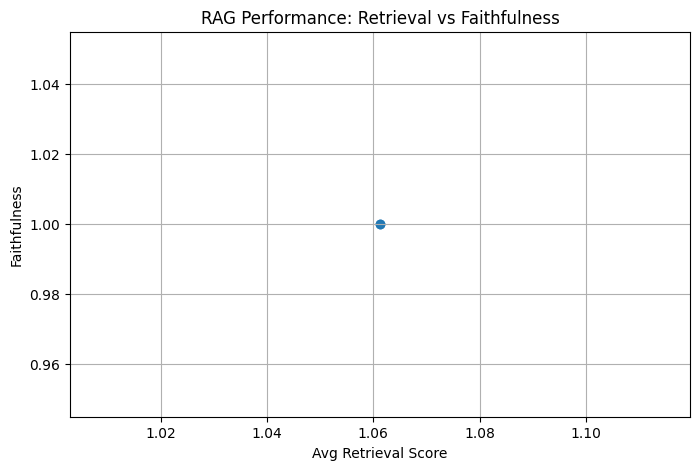

                          query  \
0         BTC market sentiment?   
1                Ethereum news?   
2  Crypto fear and greed index?   

                                            response  faithfulness  \
0  zk - starks - neptune cash and the post - quan...           1.0   
1  zk - starks - neptune cash and the post - quan...           1.0   
2  zk - starks - neptune cash and the post - quan...           1.0   

   avg_retrieval_score  
0              1.06129  
1              1.06129  
2              1.06129  


In [4]:
import pandas as pd

queries = [
    "BTC market sentiment?",
    "Ethereum news?",
    "Crypto fear and greed index?"
]
k = 3

results = []
for q in queries:
    contexts = retriever.retrieve(q, k=k)
    response = generator.generate(q, contexts)
    faith = faithfulness(response, [c['content'] for c in contexts])
    avg_score = np.mean([c['score'] for c in contexts]) if contexts else 0
    results.append({"query": q, "response": response[:100] + "...", "faithfulness": faith, "avg_retrieval_score": avg_score})
    print(f"Q: {q} | Faith: {faith:.3f} | Avg Score: {avg_score:.3f}")

df = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
plt.scatter(df['avg_retrieval_score'], df['faithfulness'], alpha=0.7)
plt.xlabel('Avg Retrieval Score')
plt.ylabel('Faithfulness')
plt.title('RAG Performance: Retrieval vs Faithfulness')
plt.grid(True)
plt.show()
print(df)

In [5]:
test_queries = [
    {
        'query': 'BTC market sentiment?',
        'ground_truth_relevant_docs': [
            'Bitcoin News: Bears Battle Critical Support Zone as BTC...',
            'Why is Bitcoin called digital gold if its underperforming gold?...',
            'How Japan’s Crypto Insider Trading Ban Could Reshape Global Policy'
        ]
    },
    {
        'query': 'Ethereum news?',
        'ground_truth_relevant_docs': [
            'Fraud experts explain growing cryptocurrency-based scams...',
            'This is the recipe for a successful crypto currency'
        ]
    }
]

metrics = evaluate_rag(test_queries, retriever, generator, k=3)
print("Eval Metrics:", metrics)

from modules.sentiment.evaluation.rag_metrics import evaluate_and_log_rag
evaluate_and_log_rag(test_queries, retriever, generator, k=3, run_params={"test_set": "btc_eth_sentiment"})

Batches: 100%|██████████| 1/1 [00:00<00:00, 36.35it/s]
INFO:httpx:HTTP Request: POST http://localhost:6333/collections/crypto_rag/points/search "HTTP/1.1 200 OK"
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
INFO:modules.sentiment.rag.generator:Generated response for query: BTC market sentiment?...
Batches: 100%|██████████| 1/1 [00:00<00:00, 38.13it/s]
INFO:httpx:HTTP Request: POST http://localhost:6333/collections/crypto_rag/points/search "HTTP/1.1 200 OK"
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
INFO:modules.sentiment.rag.generator:Generated response for query: Ethereum news?...

Eval Metrics: {'avg_precision': 0.0, 'avg_recall': 0.0, 'avg_faithfulness': 1.0}


Batches: 100%|██████████| 1/1 [00:00<00:00, 27.65it/s]
INFO:httpx:HTTP Request: POST http://localhost:6333/collections/crypto_rag/points/search "HTTP/1.1 200 OK"
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
INFO:modules.sentiment.rag.generator:Generated response for query: BTC market sentiment?...
Batches: 100%|██████████| 1/1 [00:00<00:00, 36.22it/s]
INFO:httpx:HTTP Request: POST http://localhost:6333/collections/crypto_rag/points/search "HTTP/1.1 200 OK"
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
INFO:modules.sentiment.rag.generator:Generated response for query: Ethereum news?...

🏃 View run rag_eval at: http://localhost:5000/#/experiments/39/runs/1befafd9dfda409bbaea3432b63345a1
🧪 View experiment at: http://localhost:5000/#/experiments/39


{'avg_precision': 0.0, 'avg_recall': 0.0, 'avg_faithfulness': 1.0}